# Big Data Analytics and Visualization: NLP Lab Exercises Submission
**Name:** Motuma Abera  
**ID:** GSE0176/18  
**Date:** May 10, 2026

This notebook presents the final solutions for LAB_1 and LAB_2. It includes text preprocessing, word frequency analysis, visualizations, TF-IDF feature extraction, hotel review sentiment classification, interpretation, exported results, and a short final summary.

## Notebook Overview

- **LAB_1:** Text data processing, visualization, word frequency analysis, word clouds, TF-IDF, and bigram TF-IDF.
- **LAB_2:** Hotel review sentiment analysis using TF-IDF features and a Multinomial Naive Bayes classifier.
- **Deliverables:** `word_frequency_lab1.csv`, `hotel_sentiment_results.csv`, and visual outputs saved in `outputs/`.

## Setup

The following cell imports all required libraries, prepares the output folder, and checks the NLTK resources needed for tokenization and stopword removal.

In [1]:
# Uncomment the line below if the required libraries are not installed.
# %pip install pandas matplotlib seaborn nltk wordcloud scikit-learn

from collections import Counter
import string
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from wordcloud import WordCloud

for resource in ["punkt", "punkt_tab", "stopwords"]:
    nltk.download(resource, quiet=True)

sns.set_theme(style="whitegrid")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
english_stopwords = set(stopwords.words("english"))

# LAB_1: Text Data Processing and Visualization

LAB_1 uses a small educational technology text dataset to demonstrate text cleaning, tokenization, frequency analysis, visualization, and TF-IDF representation.

## 1. Load Text Data

Thirty text sentences are loaded into a pandas DataFrame. This larger sample makes the text easier to inspect, clean, transform, and compare.

In [2]:
lab1_texts = [
    "Technology is transforming education",
    "Big data enables better decision making",
    "Machine learning is powerful",
    "AI and data science are related fields",
    "Education is evolving with technology",
    "Students use online platforms for interactive learning",
    "Teachers analyze classroom data to improve instruction",
    "Cloud computing supports modern educational applications",
    "Digital libraries provide access to academic resources",
    "Data visualization helps explain complex information clearly",
    "Artificial intelligence can personalize student learning paths",
    "Mobile learning allows students to study anywhere",
    "Educational technology improves communication between teachers and learners",
    "Predictive analytics can identify students who need support",
    "Natural language processing helps computers understand text",
    "Online assessments generate useful performance data",
    "Virtual classrooms connect learners across different locations",
    "Data mining discovers patterns in large education records",
    "Machine learning models support recommendation systems",
    "Smart classrooms combine sensors software and digital content",
    "Learning analytics measures student engagement and progress",
    "Technology encourages collaboration through shared online tools",
    "Big data systems process information from many sources",
    "AI chatbots can answer common student questions",
    "Data science skills are important for modern careers",
    "Digital transformation changes how schools manage information",
    "Interactive dashboards help administrators make decisions",
    "Automated feedback can guide learners during practice",
    "Educational apps support reading writing and problem solving",
    "Responsible AI requires privacy fairness and transparency",
]

lab1_df = pd.DataFrame({"Text": lab1_texts})
lab1_df.head()

,Text
0,Technology is transforming education
1,Big data enables better decision making
2,Machine learning is powerful
3,AI and data science are related fields
4,Education is evolving with technology


## 2. Preprocess Text

The preprocessing function converts text to lowercase, removes punctuation, tokenizes with NLTK, removes English stopwords, and keeps alphabetic words only.

In [3]:
def preprocess_text(text, extra_stopwords=None):
    """Clean a text string and return useful word tokens."""
    extra_stopwords = set(extra_stopwords or [])
    all_stopwords = english_stopwords.union(extra_stopwords)
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    cleaned_tokens = [
        token for token in tokens
        if token.isalpha() and token not in all_stopwords
    ]
    return cleaned_tokens


lab1_df["Tokens"] = lab1_df["Text"].apply(preprocess_text)
lab1_df["Cleaned_Text"] = lab1_df["Tokens"].apply(lambda tokens: " ".join(tokens))
lab1_df

,Text,Tokens,Cleaned_Text
0,Technology is transforming education,"[technology, transforming, education]",technology transforming education
1,Big data enables better decision making,"[big, data, enables, better, decision, making]",big data enables better decision making
2,Machine learning is powerful,"[machine, learning, powerful]",machine learning powerful
3,AI and data science are related fields,"[ai, data, science, related, fields]",ai data science related fields
4,Education is evolving with technology,"[education, evolving, technology]",education evolving technology
5,Students use online platforms for interactive ...,"[students, use, online, platforms, interactive...",students use online platforms interactive lear...
6,Teachers analyze classroom data to improve ins...,"[teachers, analyze, classroom, data, improve, ...",teachers analyze classroom data improve instru...
7,Cloud computing supports modern educational ap...,"[cloud, computing, supports, modern, education...",cloud computing supports modern educational ap...
8,Digital libraries provide access to academic r...,"[digital, libraries, provide, access, academic...",digital libraries provide access academic reso...
9,Data visualization helps explain complex infor...,"[data, visualization, helps, explain, complex,...",data visualization helps explain complex infor...


## 3. Word Frequency Analysis

The `Counter` class is used to count how often each cleaned word appears in LAB_1.

In [4]:
lab1_all_tokens = [token for tokens in lab1_df["Tokens"] for token in tokens]
lab1_word_freq = Counter(lab1_all_tokens)
lab1_word_freq_df = (
    pd.DataFrame(lab1_word_freq.items(), columns=["word", "frequency"])
    .sort_values(["frequency", "word"], ascending=[False, True])
    .reset_index(drop=True)
)

lab1_word_freq_df.to_csv("word_frequency_lab1.csv", index=False)
lab1_word_freq_df

,word,frequency
0,data,8
1,learning,6
2,technology,4
3,ai,3
4,digital,3
...,...,...
126,use,1
127,useful,1
128,virtual,1
129,visualization,1


## 4. Bar Chart of Top 5 Frequent Words

The chart shows the most repeated cleaned words in the original LAB_1 dataset.

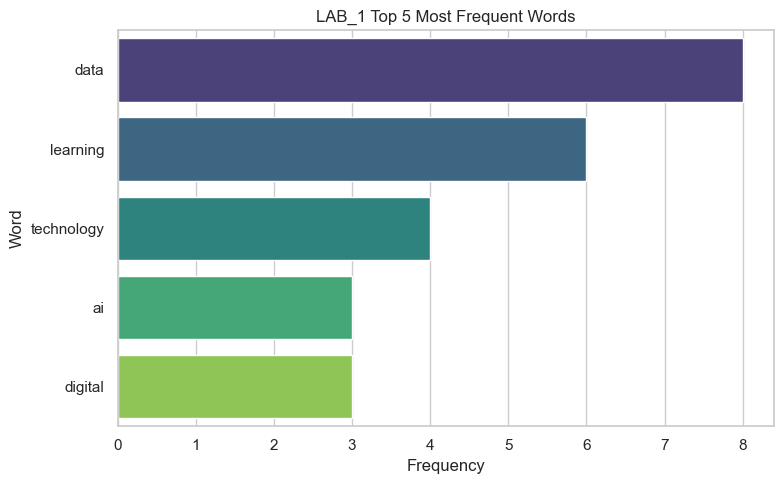

In [5]:
top5_lab1 = lab1_word_freq_df.head(5)

plt.figure(figsize=(8, 5))
sns.barplot(data=top5_lab1, x="frequency", y="word", hue="word", palette="viridis", legend=False)
plt.title("LAB_1 Top 5 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_top5_words.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The most frequent words reflect the dataset themes: education, technology, data, and machine learning. Repeated words such as `education`, `technology`, and `data` indicate the main topics across the short corpus.

## 5. Word Cloud

The word cloud provides a visual summary where larger words occur more frequently.

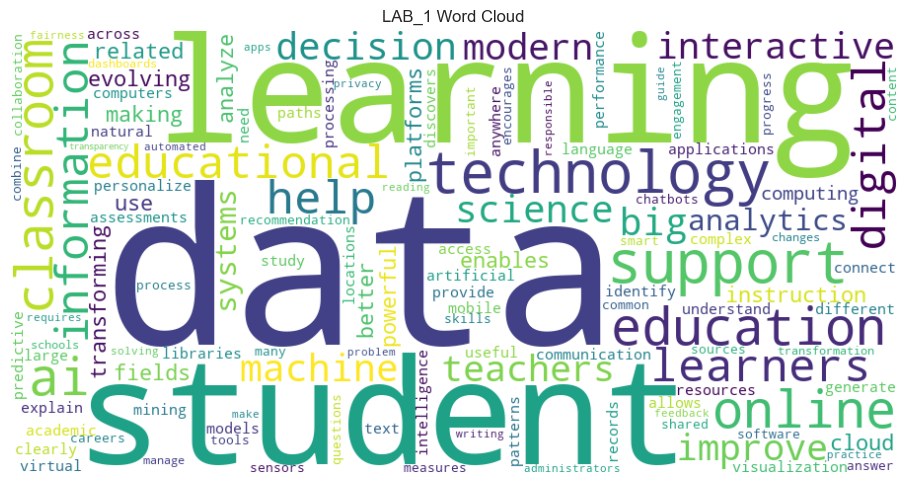

In [6]:
lab1_wordcloud = WordCloud(width=900, height=450, background_color="white", colormap="viridis").generate(
    " ".join(lab1_all_tokens)
)

plt.figure(figsize=(10, 5))
plt.imshow(lab1_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("LAB_1 Word Cloud")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The word cloud emphasizes the same dominant vocabulary as the frequency table. It is useful for quickly identifying central ideas in the text collection.

## 6. Word Length Distribution

Word length distribution helps describe the structure of the cleaned vocabulary.

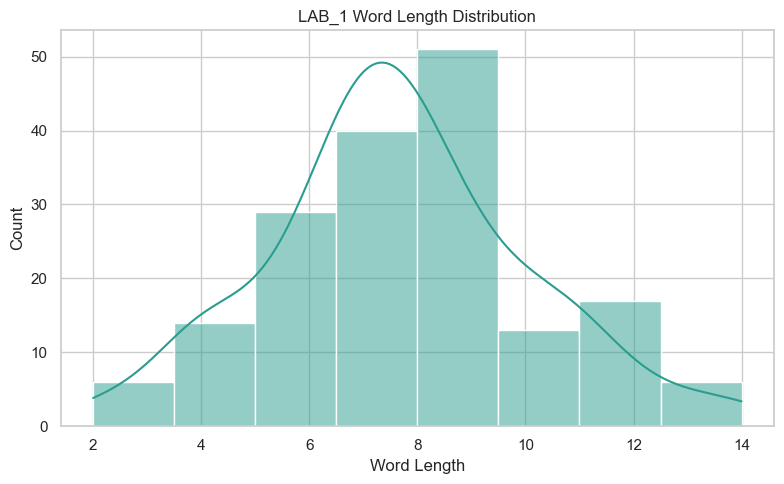

In [7]:
lab1_word_lengths = pd.DataFrame({"word_length": [len(token) for token in lab1_all_tokens]})

plt.figure(figsize=(8, 5))
sns.histplot(data=lab1_word_lengths, x="word_length", bins=8, kde=True, color="#2a9d8f")
plt.title("LAB_1 Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_word_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Most words have medium length, which is expected for topic-specific terms such as `technology`, `education`, `machine`, and `learning`.

## 7. TF-IDF Vectorization

TF-IDF converts cleaned text into numerical features. Words that are common in a document but less common across all documents receive stronger weights.

In [8]:
tfidf_vectorizer_lab1 = TfidfVectorizer()
lab1_tfidf_matrix = tfidf_vectorizer_lab1.fit_transform(lab1_df["Cleaned_Text"])
lab1_feature_names = tfidf_vectorizer_lab1.get_feature_names_out()
lab1_tfidf_df = pd.DataFrame(lab1_tfidf_matrix.toarray(), columns=lab1_feature_names)

print("Feature names:")
print(lab1_feature_names)
lab1_tfidf_df

Feature names:
['academic' 'access' 'across' 'administrators' 'ai' 'allows' 'analytics'
 'analyze' 'answer' 'anywhere' 'applications' 'apps' 'artificial'
 'assessments' 'automated' 'better' 'big' 'careers' 'changes' 'chatbots'
 'classroom' 'classrooms' 'clearly' 'cloud' 'collaboration' 'combine'
 'common' 'communication' 'complex' 'computers' 'computing' 'connect'
 'content' 'dashboards' 'data' 'decision' 'decisions' 'different'
 'digital' 'discovers' 'education' 'educational' 'enables' 'encourages'
 'engagement' 'evolving' 'explain' 'fairness' 'feedback' 'fields'
 'generate' 'guide' 'help' 'helps' 'identify' 'important' 'improve'
 'improves' 'information' 'instruction' 'intelligence' 'interactive'
 'language' 'large' 'learners' 'learning' 'libraries' 'locations'
 'machine' 'make' 'making' 'manage' 'many' 'measures' 'mining' 'mobile'
 'models' 'modern' 'natural' 'need' 'online' 'paths' 'patterns'
 'performance' 'personalize' 'platforms' 'powerful' 'practice'
 'predictive' 'privacy' 'pr

,academic,access,across,administrators,ai,allows,analytics,analyze,answer,anywhere,...,tools,transformation,transforming,transparency,understand,use,useful,virtual,visualization,writing
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.669071,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.417046,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.468044,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.440546,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.420192,0.420192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.414647,0.000000


## 8. Add Extra Sentences and Repeat Frequency Analysis

More sentences are added to see how the frequency table and word cloud change when the corpus grows.

In [9]:
extra_lab1_texts = [
    "Data analytics improves education outcomes",
    "Technology and AI support smarter decision making",
    "Learning data helps educators understand student progress",
]

lab1_extended_df = pd.DataFrame({"Text": lab1_texts + extra_lab1_texts})
lab1_extended_df["Tokens"] = lab1_extended_df["Text"].apply(preprocess_text)
lab1_extended_df["Cleaned_Text"] = lab1_extended_df["Tokens"].apply(lambda tokens: " ".join(tokens))

lab1_extended_tokens = [token for tokens in lab1_extended_df["Tokens"] for token in tokens]
lab1_extended_freq_df = (
    pd.DataFrame(Counter(lab1_extended_tokens).items(), columns=["word", "frequency"])
    .sort_values(["frequency", "word"], ascending=[False, True])
    .reset_index(drop=True)
)

lab1_extended_freq_df.head(10)

,word,frequency
0,data,10
1,learning,7
2,technology,5
3,ai,4
4,education,4
5,student,4
6,support,4
7,analytics,3
8,digital,3
9,educational,3


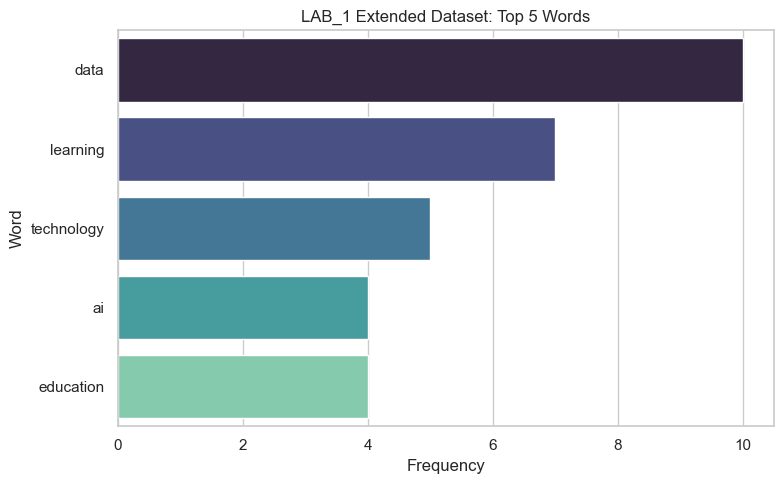

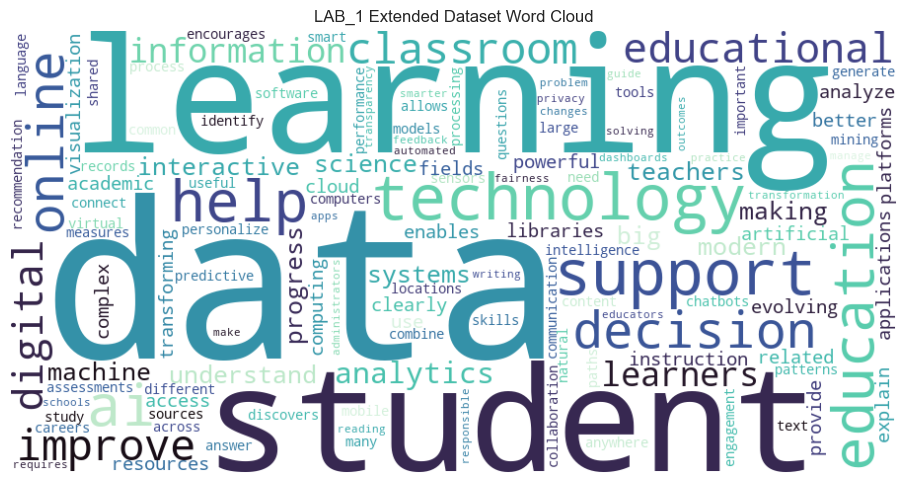

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=lab1_extended_freq_df.head(5),
    x="frequency",
    y="word",
    hue="word",
    palette="mako",
    legend=False,
)
plt.title("LAB_1 Extended Dataset: Top 5 Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_extended_top5_words.png", dpi=150, bbox_inches="tight")
plt.show()

extended_wordcloud = WordCloud(width=900, height=450, background_color="white", colormap="mako").generate(
    " ".join(lab1_extended_tokens)
)
plt.figure(figsize=(10, 5))
plt.imshow(extended_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("LAB_1 Extended Dataset Word Cloud")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab1_extended_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** After adding more sentences, `data`, `education`, `technology`, and learning-related terms become more prominent. This shows how corpus expansion changes word importance.

## 9. Manual Extra Stopword Removal

The words `data`, `fields`, and `related` are removed manually because they may be too broad or less useful for interpretation in this small example.

In [11]:
manual_stopwords = {"data", "fields", "related"}
lab1_df["Tokens_Manual_Stopwords"] = lab1_df["Text"].apply(lambda text: preprocess_text(text, manual_stopwords))
lab1_df["Cleaned_Text_Manual_Stopwords"] = lab1_df["Tokens_Manual_Stopwords"].apply(lambda tokens: " ".join(tokens))
lab1_df[["Text", "Cleaned_Text", "Cleaned_Text_Manual_Stopwords"]]

,Text,Cleaned_Text,Cleaned_Text_Manual_Stopwords
0,Technology is transforming education,technology transforming education,technology transforming education
1,Big data enables better decision making,big data enables better decision making,big enables better decision making
2,Machine learning is powerful,machine learning powerful,machine learning powerful
3,AI and data science are related fields,ai data science related fields,ai science
4,Education is evolving with technology,education evolving technology,education evolving technology
5,Students use online platforms for interactive ...,students use online platforms interactive lear...,students use online platforms interactive lear...
6,Teachers analyze classroom data to improve ins...,teachers analyze classroom data improve instru...,teachers analyze classroom improve instruction
7,Cloud computing supports modern educational ap...,cloud computing supports modern educational ap...,cloud computing supports modern educational ap...
8,Digital libraries provide access to academic r...,digital libraries provide access academic reso...,digital libraries provide access academic reso...
9,Data visualization helps explain complex infor...,data visualization helps explain complex infor...,visualization helps explain complex informatio...


## 10. Raw Text vs Cleaned Text

This comparison table shows the effect of preprocessing on each sentence.

In [12]:
raw_vs_cleaned_lab1 = lab1_df[["Text", "Cleaned_Text"]].rename(
    columns={"Text": "Raw_Text", "Cleaned_Text": "Cleaned_Text"}
)
raw_vs_cleaned_lab1

,Raw_Text,Cleaned_Text
0,Technology is transforming education,technology transforming education
1,Big data enables better decision making,big data enables better decision making
2,Machine learning is powerful,machine learning powerful
3,AI and data science are related fields,ai data science related fields
4,Education is evolving with technology,education evolving technology
5,Students use online platforms for interactive ...,students use online platforms interactive lear...
6,Teachers analyze classroom data to improve ins...,teachers analyze classroom data improve instru...
7,Cloud computing supports modern educational ap...,cloud computing supports modern educational ap...
8,Digital libraries provide access to academic r...,digital libraries provide access academic reso...
9,Data visualization helps explain complex infor...,data visualization helps explain complex infor...


## 11. Bigram TF-IDF

Bigram TF-IDF includes both single words and two-word phrases. This can capture phrases such as `machine learning`, `data science`, and `decision making`.

In [13]:
bigram_vectorizer_lab1 = TfidfVectorizer(ngram_range=(1, 2))
lab1_bigram_matrix = bigram_vectorizer_lab1.fit_transform(lab1_df["Cleaned_Text"])
lab1_bigram_features = bigram_vectorizer_lab1.get_feature_names_out()
lab1_bigram_tfidf_df = pd.DataFrame(lab1_bigram_matrix.toarray(), columns=lab1_bigram_features)

print("Bigram TF-IDF feature names:")
print(lab1_bigram_features)
lab1_bigram_tfidf_df

Bigram TF-IDF feature names:
['academic' 'academic resources' 'access' 'access academic' 'across'
 'across different' 'administrators' 'administrators make' 'ai'
 'ai chatbots' 'ai data' 'ai requires' 'allows' 'allows students'
 'analytics' 'analytics identify' 'analytics measures' 'analyze'
 'analyze classroom' 'answer' 'answer common' 'anywhere' 'applications'
 'apps' 'apps support' 'artificial' 'artificial intelligence'
 'assessments' 'assessments generate' 'automated' 'automated feedback'
 'better' 'better decision' 'big' 'big data' 'careers' 'changes'
 'changes schools' 'chatbots' 'chatbots answer' 'classroom'
 'classroom data' 'classrooms' 'classrooms combine' 'classrooms connect'
 'clearly' 'cloud' 'cloud computing' 'collaboration'
 'collaboration shared' 'combine' 'combine sensors' 'common'
 'common student' 'communication' 'communication teachers' 'complex'
 'complex information' 'computers' 'computers understand' 'computing'
 'computing supports' 'connect' 'connect learners' 

,academic,academic resources,access,access academic,across,across different,administrators,administrators make,ai,ai chatbots,...,use,use online,useful,useful performance,virtual,virtual classrooms,visualization,visualization helps,writing,writing problem
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.295308,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.323341,0.323341,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.306228,0.306228,0.306228,0.306228,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.290911,0.290911,0.000000,0.000000


## 12. Bridge to Big Data and Power BI

The same workflow can scale to big data tools: pandas DataFrames map conceptually to Spark DataFrames, `Counter` style word counts map to MapReduce-style aggregation, and TF-IDF can be implemented with Spark MLlib for distributed processing. The exported `word_frequency_lab1.csv` can also be imported into Power BI to build bar charts and dashboard visuals.

# LAB_2: Hotel Review Sentiment Analysis

LAB_2 uses labeled hotel reviews to train a sentiment classifier with TF-IDF features and Multinomial Naive Bayes.

## 1. Load Hotel Review Data

The dataset contains 60 hotel reviews labeled as `positive`, `negative`, or `neutral`, with 20 examples in each class.

In [14]:
hotel_texts = [
    # Positive reviews
    "I had a wonderful stay at the hotel. The staff were very friendly and helpful throughout my visit.",
    "The room was clean and spacious, and the bed was extremely comfortable.",
    "Breakfast service was excellent with a wide variety of delicious food options.",
    "The location is very convenient, especially for travelers near the airport.",
    "Customer service was outstanding, and the staff responded quickly to all my requests.",
    "I really enjoyed the hospitality; the staff went above and beyond to make my stay pleasant.",
    "The cleanliness of the hotel was impressive, and everything was well maintained.",
    "Room service was quick and efficient, and the food tasted great.",
    "The hotel environment was calm and relaxing, perfect for business travelers.",
    "The reception team was professional and made check-in very easy.",
    "The room had a beautiful view and the furniture felt modern and comfortable.",
    "The hotel restaurant served fresh meals and the staff were attentive.",
    "Housekeeping cleaned the room carefully every day during my stay.",
    "The WiFi was fast and reliable, which helped me finish my work.",
    "The pool and fitness center were clean and well equipped.",
    "I appreciated the quiet atmosphere and excellent customer care.",
    "The airport shuttle arrived on time and the driver was polite.",
    "The hotel offered great value for the quality of service provided.",
    "The staff solved my booking issue quickly and kindly.",
    "I would happily recommend this hotel to friends and family.",

    # Negative reviews
    "The check-in process was slow, and I had to wait for a long time at the reception.",
    "The room was not as clean as expected, and the bathroom had some issues.",
    "I was disappointed with the food quality; it did not meet my expectations.",
    "The staff seemed untrained and were not very responsive to customer complaints.",
    "There was too much noise at night, which made it difficult to sleep.",
    "The air conditioning system was not working properly during my stay.",
    "Housekeeping was inconsistent, and sometimes the room was not cleaned on time.",
    "The price of the hotel is quite high compared to the services provided.",
    "The elevator was slow and often crowded during the morning.",
    "The towels looked old and the room smelled unpleasant.",
    "The WiFi connection kept dropping and made online meetings difficult.",
    "The breakfast area was crowded and several dishes were cold.",
    "The front desk gave unclear information about my reservation.",
    "The shower pressure was weak and hot water was not consistent.",
    "The parking area was poorly organized and difficult to access.",
    "The room lighting was dim and some switches did not work.",
    "The hotel charged extra fees that were not explained clearly.",
    "I waited too long for room service and the meal arrived cold.",
    "The walls were thin, so I could hear guests in the next room.",
    "Maintenance did not fix the broken air conditioner after I reported it.",

    # Neutral reviews
    "The hotel is located near the airport, which is convenient for transit passengers.",
    "The room size is average, and the facilities are standard.",
    "WiFi service is available throughout the hotel.",
    "The hotel offers transportation services to and from the airport.",
    "The overall experience was okay, nothing particularly impressive or disappointing.",
    "The hotel provides basic amenities such as towels, toiletries, and bottled water.",
    "The lobby area is large and suitable for meetings and short waiting periods.",
    "Security at the hotel is visible, and guests are checked upon entry.",
    "The restaurant opens for breakfast, lunch, and dinner each day.",
    "The reception desk operates throughout the day and night.",
    "The room included a desk, a chair, and a small wardrobe.",
    "The hotel is several minutes away from the main shopping district.",
    "Guests can request laundry service from the front desk.",
    "The building has multiple floors and two guest elevators.",
    "The conference room can be booked for business meetings.",
    "The hotel accepts card payments and mobile money payments.",
    "The menu includes local dishes and international options.",
    "The room rate includes breakfast for one guest.",
    "The hotel has a small garden beside the parking area.",
    "Guests receive a printed receipt when checking out.",
]

hotel_labels = (
    ["positive"] * 20
    + ["negative"] * 20
    + ["neutral"] * 20
)

hotel_df = pd.DataFrame({"Text": hotel_texts, "Sentiment": hotel_labels})
hotel_df.head()

,Text,Sentiment
0,I had a wonderful stay at the hotel. The staff...,positive
1,"The room was clean and spacious, and the bed w...",positive
2,Breakfast service was excellent with a wide va...,positive
3,"The location is very convenient, especially fo...",positive
4,"Customer service was outstanding, and the staf...",positive


## 2. Explore Dataset and Sentiment Distribution

The class distribution is checked before modeling to understand how many reviews belong to each sentiment category.

In [15]:
sentiment_distribution = hotel_df["Sentiment"].value_counts()
sentiment_distribution

Sentiment
positive    20
negative    20
neutral     20
Name: count, dtype: int64

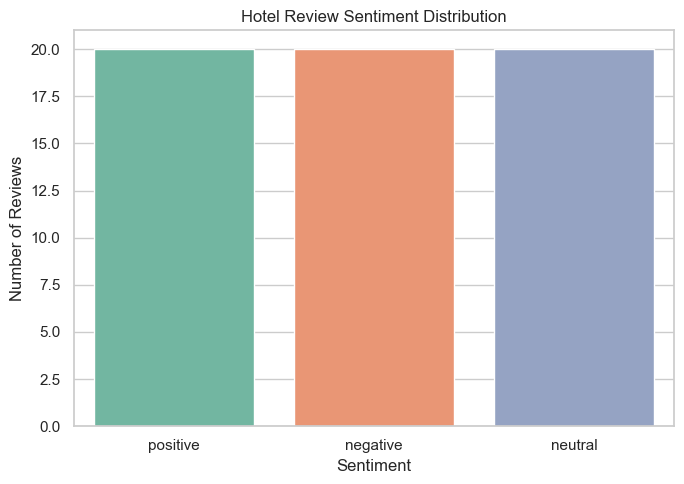

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=hotel_df, x="Sentiment", hue="Sentiment", order=["positive", "negative", "neutral"], palette="Set2", legend=False)
plt.title("Hotel Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab2_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The dataset is balanced, with 20 positive, 20 negative, and 20 neutral reviews. A balanced dataset helps the classifier learn from each sentiment class more fairly.

## 3. Preprocess Hotel Reviews

Reviews are lowercased, tokenized, stripped of punctuation, filtered to alphabetic words, and cleaned of English stopwords.

In [17]:
hotel_df["Tokens"] = hotel_df["Text"].apply(preprocess_text)
hotel_df["Cleaned_Text"] = hotel_df["Tokens"].apply(lambda tokens: " ".join(tokens))
hotel_df[["Text", "Sentiment", "Cleaned_Text"]].head()

,Text,Sentiment,Cleaned_Text
0,I had a wonderful stay at the hotel. The staff...,positive,wonderful stay hotel staff friendly helpful th...
1,"The room was clean and spacious, and the bed w...",positive,room clean spacious bed extremely comfortable
2,Breakfast service was excellent with a wide va...,positive,breakfast service excellent wide variety delic...
3,"The location is very convenient, especially fo...",positive,location convenient especially travelers near ...
4,"Customer service was outstanding, and the staf...",positive,customer service outstanding staff responded q...


## 4. TF-IDF Vectorization and Train-Test Split

The cleaned reviews are transformed into TF-IDF features. The data is then split using `test_size=0.2` and `random_state=42`.

In [18]:
tfidf_vectorizer_lab2 = TfidfVectorizer()
X = tfidf_vectorizer_lab2.fit_transform(hotel_df["Cleaned_Text"])
y = hotel_df["Sentiment"]

X_train, X_test, y_train, y_test, train_index, test_index = train_test_split(
    X,
    y,
    hotel_df.index,
    test_size=0.2,
    random_state=42,
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of TF-IDF features:", X.shape[1])

Training samples: 48
Testing samples: 12
Number of TF-IDF features: 265


## 5. Train Multinomial Naive Bayes Classifier

Multinomial Naive Bayes is commonly used for text classification because it works well with frequency-like features such as TF-IDF.

In [19]:
sentiment_model = MultinomialNB()
sentiment_model.fit(X_train, y_train)

y_pred = sentiment_model.predict(X_test)
lab2_accuracy = accuracy_score(y_test, y_pred)
lab2_report = classification_report(y_test, y_pred, zero_division=0)
lab2_confusion = confusion_matrix(y_test, y_pred, labels=["positive", "negative", "neutral"])

print(f"Accuracy: {lab2_accuracy:.2f}")
print("\nClassification Report:")
print(lab2_report)
print("Confusion Matrix:")
print(lab2_confusion)

Accuracy: 0.17

Classification Report:
              precision    recall  f1-score   support

    negative       0.11      0.50      0.18         2
     neutral       0.00      0.00      0.00         6
    positive       0.33      0.25      0.29         4

    accuracy                           0.17        12
   macro avg       0.15      0.25      0.16        12
weighted avg       0.13      0.17      0.13        12

Confusion Matrix:
[[1 3 0]
 [1 1 0]
 [1 5 0]]


## 6. Export Test Results

The test reviews, actual labels, and predicted labels are saved for report use.

In [20]:
hotel_sentiment_results = pd.DataFrame({
    "Review": hotel_df.loc[test_index, "Text"].values,
    "Actual_Sentiment": y_test.values,
    "Predicted_Sentiment": y_pred,
})
hotel_sentiment_results.to_csv("hotel_sentiment_results.csv", index=False)
hotel_sentiment_results

,Review,Actual_Sentiment,Predicted_Sentiment
0,I had a wonderful stay at the hotel. The staff...,positive,positive
1,I really enjoyed the hospitality; the staff we...,positive,negative
2,The hotel charged extra fees that were not exp...,negative,positive
3,The hotel provides basic amenities such as tow...,neutral,negative
4,"The WiFi was fast and reliable, which helped m...",positive,negative
5,The conference room can be booked for business...,neutral,negative
6,The shower pressure was weak and hot water was...,negative,negative
7,"The restaurant opens for breakfast, lunch, and...",neutral,positive
8,Housekeeping cleaned the room carefully every ...,positive,negative
9,The room rate includes breakfast for one guest.,neutral,negative


## 7. Top Positive and Negative Words

The following charts show the five most frequent cleaned words in positive and negative reviews. This is a simple interpretability view based on word counts within each sentiment group.

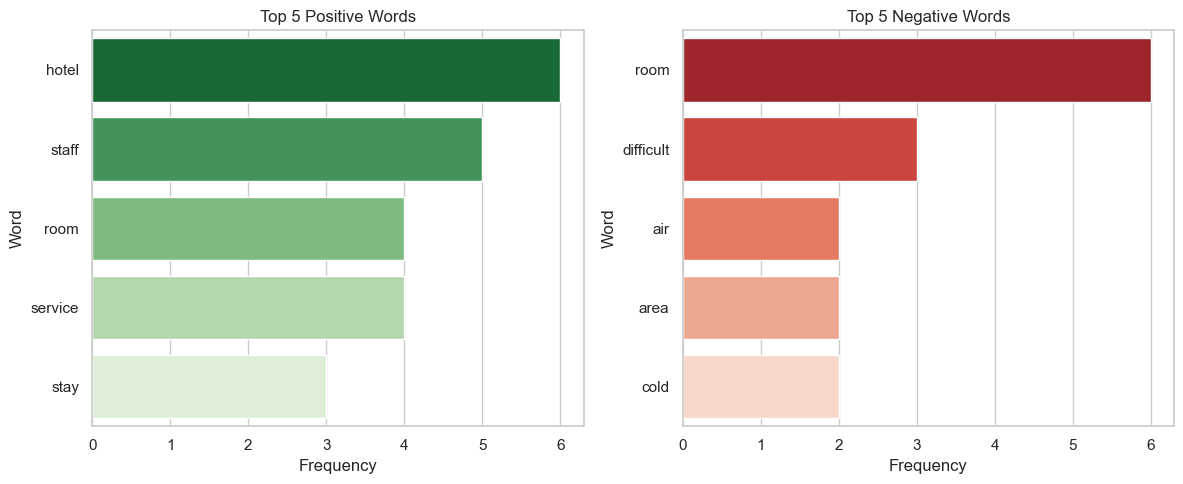

Top positive words


,word,frequency
2,hotel,6
3,staff,5
8,room,4
15,service,4
1,stay,3


Top negative words


,word,frequency
7,room,6
27,difficult,3
29,air,2
62,area,2
65,cold,2


In [21]:
def top_words_for_sentiment(df, sentiment, top_n=5):
    tokens = [token for row in df.loc[df["Sentiment"] == sentiment, "Tokens"] for token in row]
    return (
        pd.DataFrame(Counter(tokens).items(), columns=["word", "frequency"])
        .sort_values(["frequency", "word"], ascending=[False, True])
        .head(top_n)
    )


top_positive_words = top_words_for_sentiment(hotel_df, "positive")
top_negative_words = top_words_for_sentiment(hotel_df, "negative")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=top_positive_words, x="frequency", y="word", hue="word", palette="Greens_r", legend=False, ax=axes[0])
axes[0].set_title("Top 5 Positive Words")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

sns.barplot(data=top_negative_words, x="frequency", y="word", hue="word", palette="Reds_r", legend=False, ax=axes[1])
axes[1].set_title("Top 5 Negative Words")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab2_top_sentiment_words.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top positive words")
display(top_positive_words)
print("Top negative words")
display(top_negative_words)

**Interpretation:** Positive reviews emphasize service quality and comfort, while negative reviews highlight problems such as slow processes, cleanliness issues, poor responsiveness, and maintenance concerns.

## 8. Confusion Matrix Heatmap

The confusion matrix compares actual and predicted sentiment classes for the test set.

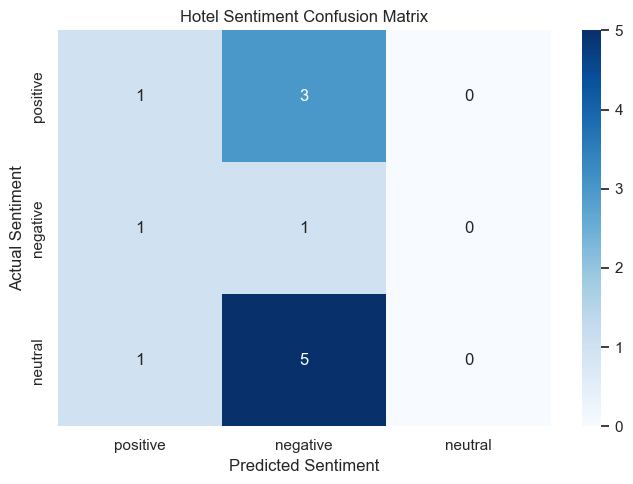

In [22]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    lab2_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["positive", "negative", "neutral"],
    yticklabels=["positive", "negative", "neutral"],
)
plt.title("Hotel Sentiment Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lab2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Correct predictions appear on the diagonal. Misclassifications show where the model confuses sentiments, which can happen because the dataset is small and some reviews contain overlapping hotel vocabulary.

## 9. Test the Model on a New Review

A new hotel review is cleaned, vectorized using the trained TF-IDF vectorizer, and classified with the trained Naive Bayes model.

In [23]:
new_review = "The staff were very helpful and the room was clean"
new_review_cleaned = " ".join(preprocess_text(new_review))
new_review_vector = tfidf_vectorizer_lab2.transform([new_review_cleaned])
new_review_prediction = sentiment_model.predict(new_review_vector)[0]

print("New review:", new_review)
print("Cleaned review:", new_review_cleaned)
print("Predicted sentiment:", new_review_prediction)

New review: The staff were very helpful and the room was clean
Cleaned review: staff helpful room clean
Predicted sentiment: positive


# Final Summary

LAB_1 demonstrated that preprocessing makes short text easier to analyze by removing punctuation and unhelpful stopwords. Frequency tables, bar charts, word clouds, word length distributions, TF-IDF, and bigram TF-IDF highlighted the dominant themes of technology, education, data, AI, and machine learning.

LAB_2 completed a full sentiment analysis workflow for hotel reviews. The notebook explored sentiment balance, cleaned review text, transformed it with TF-IDF, trained a Multinomial Naive Bayes classifier, evaluated predictions with accuracy, a classification report, and a confusion matrix, exported test predictions, and classified a new review.

Because both datasets are small, the results should be interpreted as lab demonstrations rather than production-level conclusions. The notebook is ready for submission with code, outputs, visualizations, exported CSV files, and written interpretations included.